Starting Comprehensive Diabetes Data Analysis

Loading diabetes dataset...

Step 1: Initial Data Exploration

Dataset Overview:
Number of records: 768
Number of features: 9

Feature names:
- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age
- Outcome

Generating Sweetviz Report...


                                             |                                             | [  0%]   00:00 ->…

Report diabetes_sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.

Detailed Statistical Summary:
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00           0.00     0.00    0.00   
25%           1.00    99.00          62.00           0.00     0.00   27.30   
50%           3.00   117.00          72.00          23.00    30.50   32.00   
75%           6.00   140.25          80.00          32.00   127.25   36.60   
max          17.00   199.00         122.00          99.00   846.00   67.10   

       DiabetesPedigreeFunction     Age  Outcome  
count                    768.00  768.00   768.0

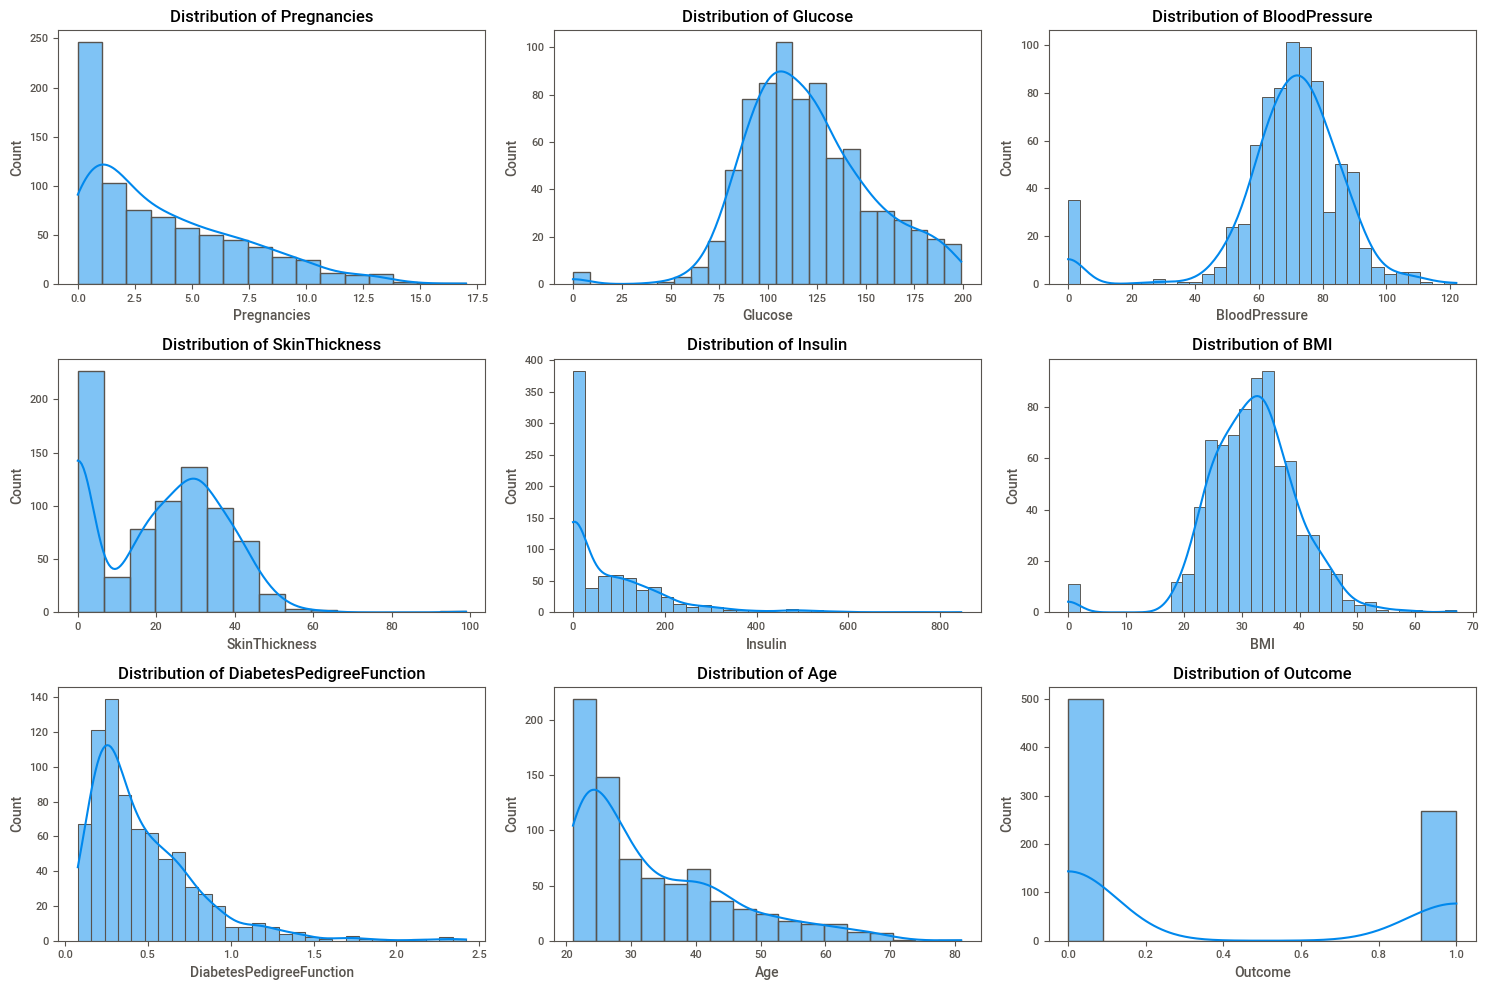


Distribution Insights:

Pregnancies:
- Skewness: 0.90 (right-skewed)
- Kurtosis: 0.16 (heavy-tailed)

Glucose:
- Skewness: 0.17 (right-skewed)
- Kurtosis: 0.64 (heavy-tailed)

BloodPressure:
- Skewness: -1.84 (left-skewed)
- Kurtosis: 5.18 (heavy-tailed)

SkinThickness:
- Skewness: 0.11 (right-skewed)
- Kurtosis: -0.52 (light-tailed)

Insulin:
- Skewness: 2.27 (right-skewed)
- Kurtosis: 7.21 (heavy-tailed)

BMI:
- Skewness: -0.43 (left-skewed)
- Kurtosis: 3.29 (heavy-tailed)

DiabetesPedigreeFunction:
- Skewness: 1.92 (right-skewed)
- Kurtosis: 5.59 (heavy-tailed)

Age:
- Skewness: 1.13 (right-skewed)
- Kurtosis: 0.64 (heavy-tailed)

Outcome:
- Skewness: 0.64 (right-skewed)
- Kurtosis: -1.60 (light-tailed)

Analyzing feature correlations...


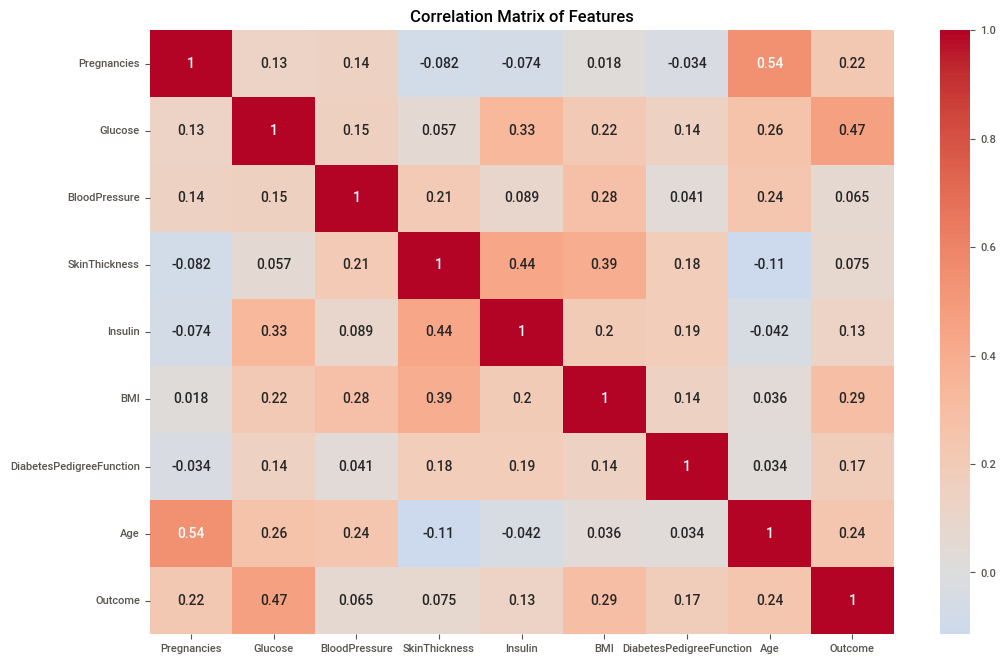


Key Correlation Insights:

Insulin and Glucose:
- Correlation: 0.33
- Interpretation: Moderate positive relationship

Insulin and SkinThickness:
- Correlation: 0.44
- Interpretation: Moderate positive relationship

BMI and SkinThickness:
- Correlation: 0.39
- Interpretation: Moderate positive relationship

Age and Pregnancies:
- Correlation: 0.54
- Interpretation: Strong positive relationship

Outcome and Glucose:
- Correlation: 0.47
- Interpretation: Moderate positive relationship

Performing outlier analysis...


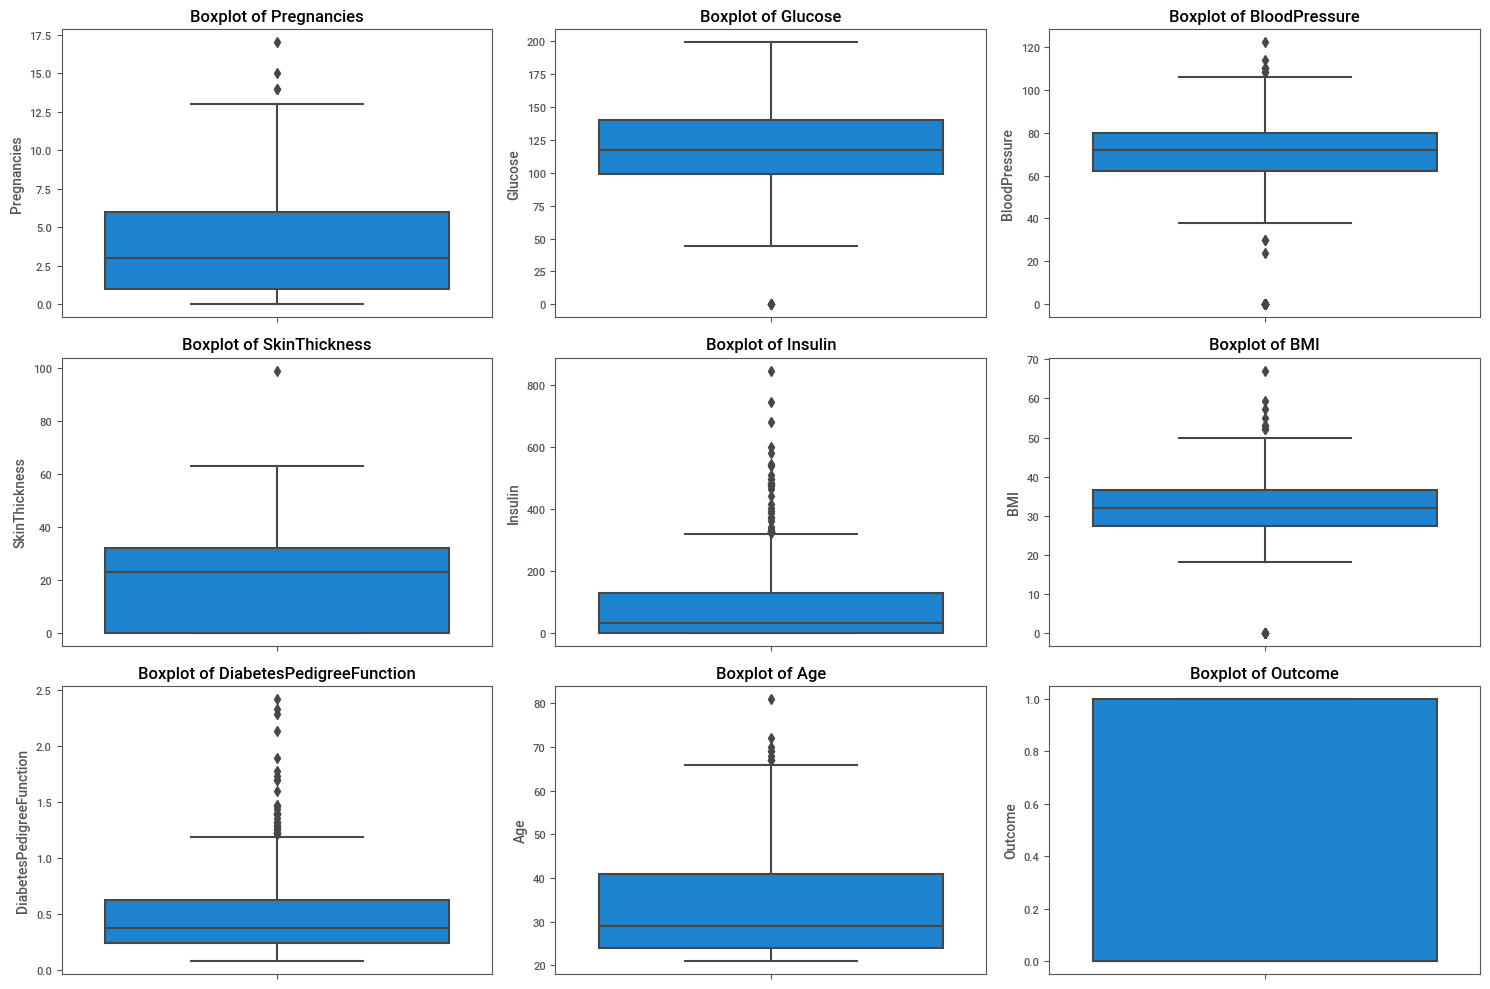


Outlier Analysis:

Pregnancies:
- Number of outliers: 4
- Percentage of outliers: 0.52%
- Range of outliers: 14.00 to 17.00

Glucose:
- Number of outliers: 5
- Percentage of outliers: 0.65%
- Range of outliers: 0.00 to 0.00

BloodPressure:
- Number of outliers: 45
- Percentage of outliers: 5.86%
- Range of outliers: 0.00 to 122.00

SkinThickness:
- Number of outliers: 1
- Percentage of outliers: 0.13%
- Range of outliers: 99.00 to 99.00

Insulin:
- Number of outliers: 34
- Percentage of outliers: 4.43%
- Range of outliers: 321.00 to 846.00

BMI:
- Number of outliers: 19
- Percentage of outliers: 2.47%
- Range of outliers: 0.00 to 67.10

DiabetesPedigreeFunction:
- Number of outliers: 29
- Percentage of outliers: 3.78%
- Range of outliers: 1.21 to 2.42

Age:
- Number of outliers: 9
- Percentage of outliers: 1.17%
- Range of outliers: 67.00 to 81.00

Outcome:
- Number of outliers: 0

Step 2: Data Preparation

Checking for duplicate records...
No duplicate records found

Checking for mis

In [3]:
# Comprehensive Diabetes Analysis with EDA and Data Preparation
# This code includes detailed data exploration and preprocessing steps

# Part 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sweetviz as sv

# For handling imbalanced data if needed

from collections import Counter

def perform_eda(data):
    """
    Performs comprehensive Exploratory Data Analysis on the diabetes dataset.
    This helps us understand our data before building prediction models.
    """
    print("\nStep 1: Initial Data Exploration")
    print("================================")
    
    # Basic dataset information
    print("\nDataset Overview:")
    print(f"Number of records: {len(data)}")
    print(f"Number of features: {len(data.columns)}")
    print("\nFeature names:")
    for col in data.columns:
        print(f"- {col}")
    
    # Generate detailed EDA report using sweetviz
    print("\nGenerating Sweetviz Report...")
    sweet_report = sv.analyze(data)
    sweet_report.show_html('diabetes_sweetviz_report.html')
    
     
    # Detailed statistical summary
    print("\nDetailed Statistical Summary:")
    stats_summary = data.describe(include='all').round(2)
    print(stats_summary)
    
    # Distribution Analysis
    print("\nCreating distribution plots for numerical features...")
    plot_distributions(data)
    
    # Correlation Analysis
    print("\nAnalyzing feature correlations...")
    plot_correlation_matrix(data)
    
    # Outlier Analysis
    print("\nPerforming outlier analysis...")
    identify_outliers(data)
    
    return stats_summary

def plot_distributions(data):
    """
    Creates distribution plots for all numerical features.
    This helps us understand the shape and spread of our data.
    """
    numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
    
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(3, 3, i)
        
        # Plot histogram with kernel density estimate
        sns.histplot(data=data, x=col, kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
    
    plt.tight_layout()
    plt.show()
    
    # Additional distribution insights
    print("\nDistribution Insights:")
    for col in numerical_cols:
        skewness = data[col].skew()
        kurtosis = data[col].kurtosis()
        print(f"\n{col}:")
        print(f"- Skewness: {skewness:.2f} ({'right-skewed' if skewness > 0 else 'left-skewed' if skewness < 0 else 'symmetric'})")
        print(f"- Kurtosis: {kurtosis:.2f} ({'heavy-tailed' if kurtosis > 0 else 'light-tailed' if kurtosis < 0 else 'normal'})")

def plot_correlation_matrix(data):
    """
    Creates and explains correlation matrix between features.
    This helps us understand relationships between different variables.
    """
    # Calculate correlations
    corr_matrix = data.corr()
    
    # Create correlation heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix of Features')
    plt.show()
    
    # Explain strong correlations
    print("\nKey Correlation Insights:")
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) >= 0.3:  # Consider correlations >= 0.3 as noteworthy
                print(f"\n{corr_matrix.index[i]} and {corr_matrix.columns[j]}:")
                print(f"- Correlation: {corr_matrix.iloc[i, j]:.2f}")
                print(f"- Interpretation: {'Strong' if abs(corr_matrix.iloc[i, j]) >= 0.5 else 'Moderate'} "
                      f"{'positive' if corr_matrix.iloc[i, j] > 0 else 'negative'} relationship")

def identify_outliers(data):
    """
    Identifies and analyzes outliers in the dataset.
    This helps us understand extreme values that might affect our models.
    """
    numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
    
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(3, 3, i)
        sns.boxplot(y=data[col])
        plt.title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()
    
    # Calculate and report outliers using IQR method
    print("\nOutlier Analysis:")
    for col in numerical_cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col]
        
        print(f"\n{col}:")
        print(f"- Number of outliers: {len(outliers)}")
        if len(outliers) > 0:
            print(f"- Percentage of outliers: {(len(outliers)/len(data))*100:.2f}%")
            print(f"- Range of outliers: {outliers.min():.2f} to {outliers.max():.2f}")

def prepare_data(data):
    """
    Performs comprehensive data preparation and cleaning.
    This ensures our data is ready for machine learning models.
    """
    print("\nStep 2: Data Preparation")
    print("=======================")
    
    # Create a copy to avoid modifying original data
    df = data.copy()
    
    # Check for duplicates
    print("\nChecking for duplicate records...")
    duplicates = df.duplicated()
    if duplicates.any():
        print(f"Found {duplicates.sum()} duplicate records")
        df = df.drop_duplicates()
        print("Duplicates removed")
    else:
        print("No duplicate records found")
    
    # Check for missing values
    print("\nChecking for missing values...")
    missing_values = df.isnull().sum()
    if missing_values.any():
        print("\nMissing values found:")
        for col in df.columns:
            missing = df[col].isnull().sum()
            if missing > 0:
                print(f"- {col}: {missing} missing values ({(missing/len(df))*100:.2f}%)")
        
        # Handle missing values
        print("\nHandling missing values...")
        for col in df.columns:
            if df[col].isnull().any():
                if df[col].dtype in ['float64', 'int64']:
                    # For numerical columns, impute with median
                    median_value = df[col].median()
                    df[col].fillna(median_value, inplace=True)
                    print(f"- Filled missing values in {col} with median: {median_value:.2f}")
                else:
                    # For categorical columns, impute with mode
                    mode_value = df[col].mode()[0]
                    df[col].fillna(mode_value, inplace=True)
                    print(f"- Filled missing values in {col} with mode: {mode_value}")
    else:
        print("No missing values found")
    
    # Handle zero values in features where zero is not possible
    print("\nChecking for invalid zero values...")
    zero_value_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI']
    for feature in zero_value_features:
        zero_count = (df[feature] == 0).sum()
        if zero_count > 0:
            print(f"\nFound {zero_count} zero values in {feature}")
            # Replace zeros with median of non-zero values
            median_non_zero = df[df[feature] != 0][feature].median()
            df.loc[df[feature] == 0, feature] = median_non_zero
            print(f"- Replaced zeros in {feature} with median of non-zero values: {median_non_zero:.2f}")
    
    # Feature scaling
    print("\nScaling numerical features...")
    numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
    scaler = StandardScaler()
    df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
    print("Features scaled to standard normal distribution")
    
        
    # Feature engineering
    print("\nPerforming feature engineering...")
    df['Glucose_BMI'] = df['Glucose'] * df['BMI']
    df['Age_BMI'] = df['Age'] * df['BMI']
    print("Created new features: Glucose_BMI, Age_BMI")
    
    return df

def main():
    """
    Main function that runs the entire analysis pipeline
    """
    print("Starting Comprehensive Diabetes Data Analysis")
    print("===========================================")
    
    # Load initial data
    print("\nLoading diabetes dataset...")
    data = pd.read_csv('diabetes.csv')
    
    # Perform EDA
    stats_summary = perform_eda(data)
    
    # Prepare data
    cleaned_data = prepare_data(data)
    
    print("\nData exploration and preparation complete!")
    print("Review the generated reports and visualizations to understand:")
    print("1. The distribution and relationships in your data")
    print("2. How missing values and outliers were handled")
    print("3. The impact of data preprocessing steps")
    
    return cleaned_data, stats_summary

if __name__ == "__main__":
    cleaned_data, stats_summary = main()

Starting Comprehensive Diabetes Prediction Analysis

This analysis will:
1. Prepare the diabetes dataset
2. Train 10 different prediction models
3. Evaluate each model's performance
4. Provide business-relevant interpretations

Starting analysis...

Step 1: Loading and preparing the data...
Creating combined features to help with predictions...
Splitting data into training and testing sets...
Scaling features to be comparable...

Training Logistic Regression...

Analyzing results for: Logistic Regression

How this algorithm works:

                Logistic Regression is like drawing a line to separate diabetic from non-diabetic patients.
                It's similar to how credit scores combine different factors with weights.
                Strengths: Simple to understand, highly interpretable
                Limitations: May miss complex patterns
            


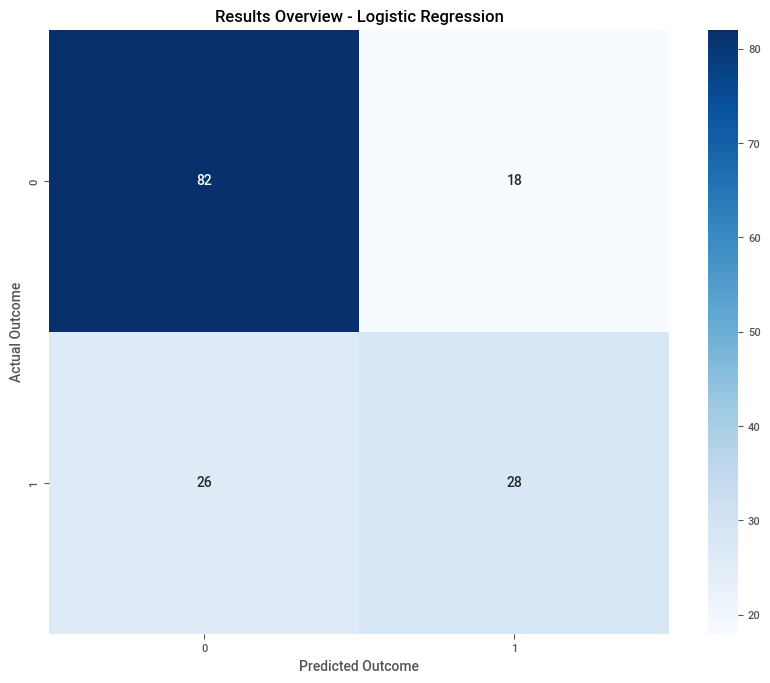


Business Impact Analysis:
Total patients analyzed: 154
Correct predictions: 110 (71.4%)
Missed diabetes cases: 26 (48.1% of actual cases)
False alarms: 18 (18.0% of healthy patients)


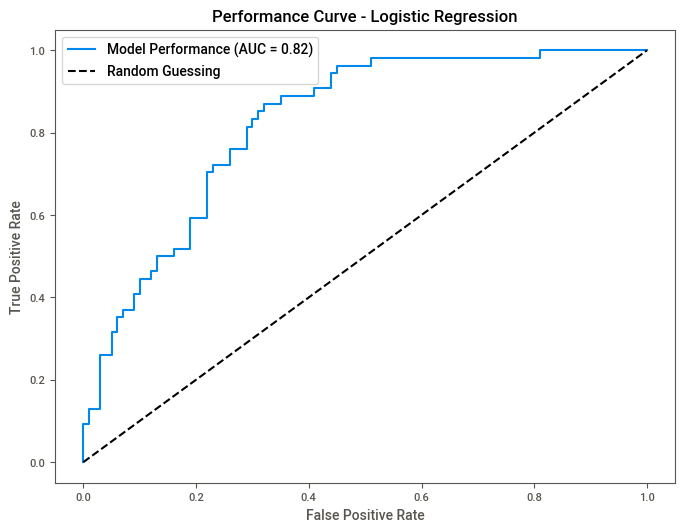


Training K-Nearest Neighbors...

Analyzing results for: K-Nearest Neighbors

How this algorithm works:

                KNN finds the 5 most similar past cases and uses their outcomes to make a prediction.
                It's like Netflix recommending movies based on similar users' preferences.
                Strengths: Intuitive, no training needed
                Limitations: Can be slow with large datasets
            


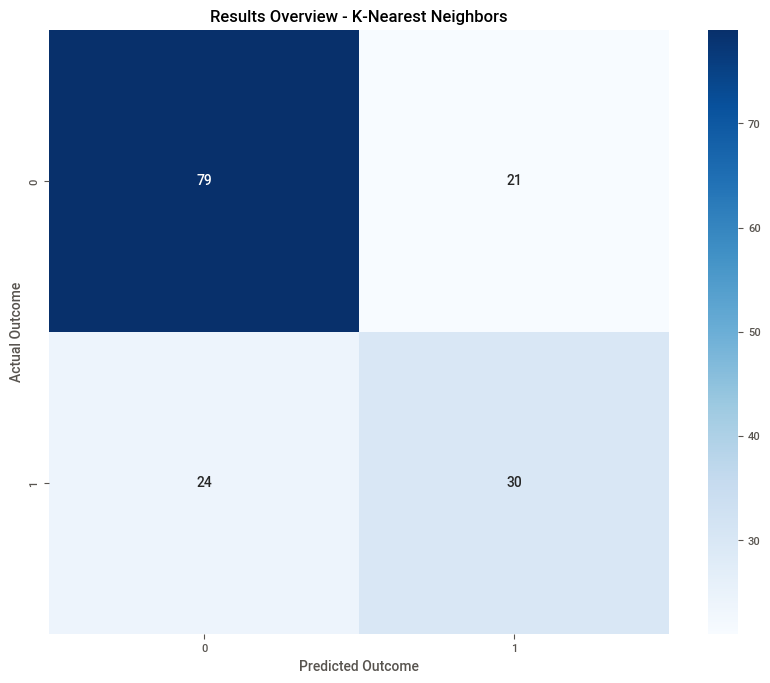


Business Impact Analysis:
Total patients analyzed: 154
Correct predictions: 109 (70.8%)
Missed diabetes cases: 24 (44.4% of actual cases)
False alarms: 21 (21.0% of healthy patients)


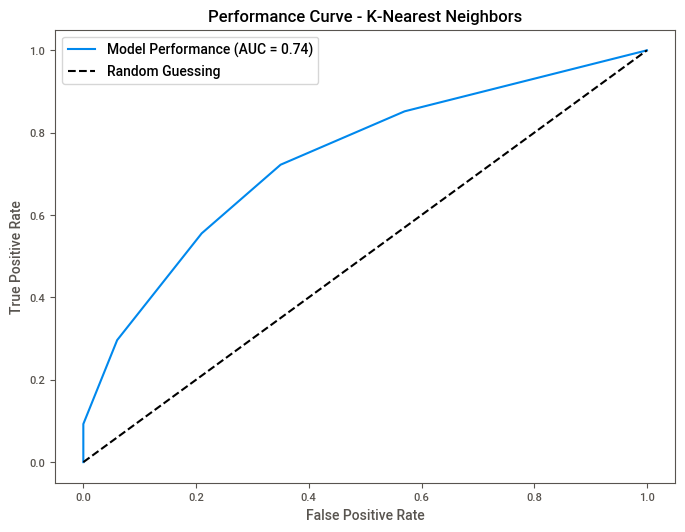


Training Decision Tree...

Analyzing results for: Decision Tree

How this algorithm works:

                Creates a flowchart of yes/no questions to reach a prediction.
                Similar to a customer service decision tree.
                Strengths: Very easy to understand, can visualize decisions
                Limitations: Can be unstable, may oversimplify
            


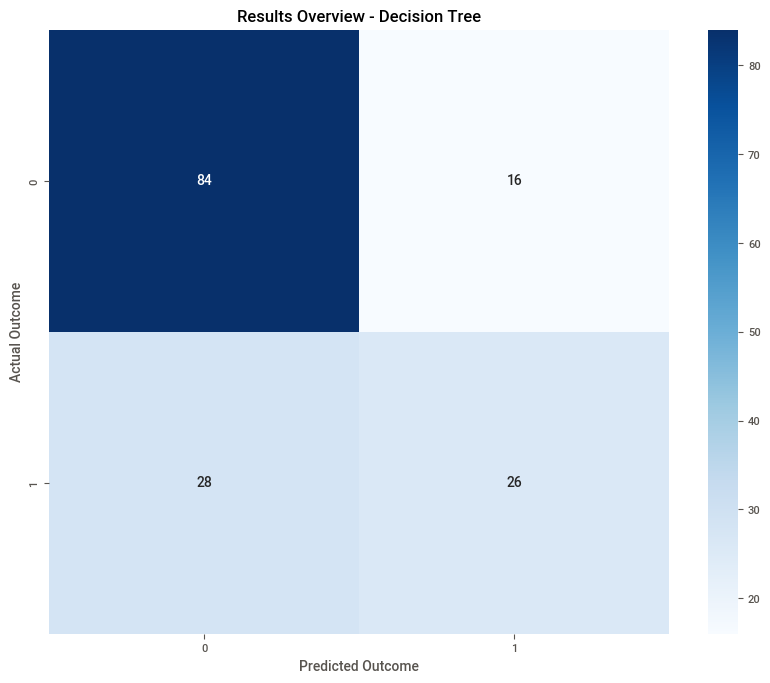


Business Impact Analysis:
Total patients analyzed: 154
Correct predictions: 110 (71.4%)
Missed diabetes cases: 28 (51.9% of actual cases)
False alarms: 16 (16.0% of healthy patients)


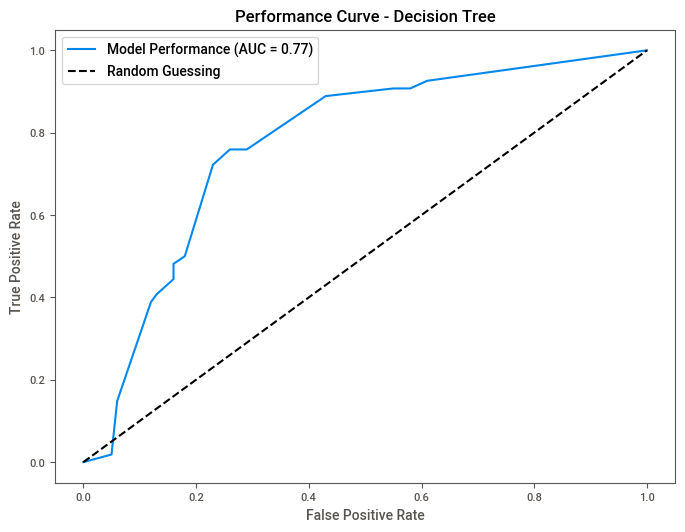


Analyzing which factors were most important for predictions...


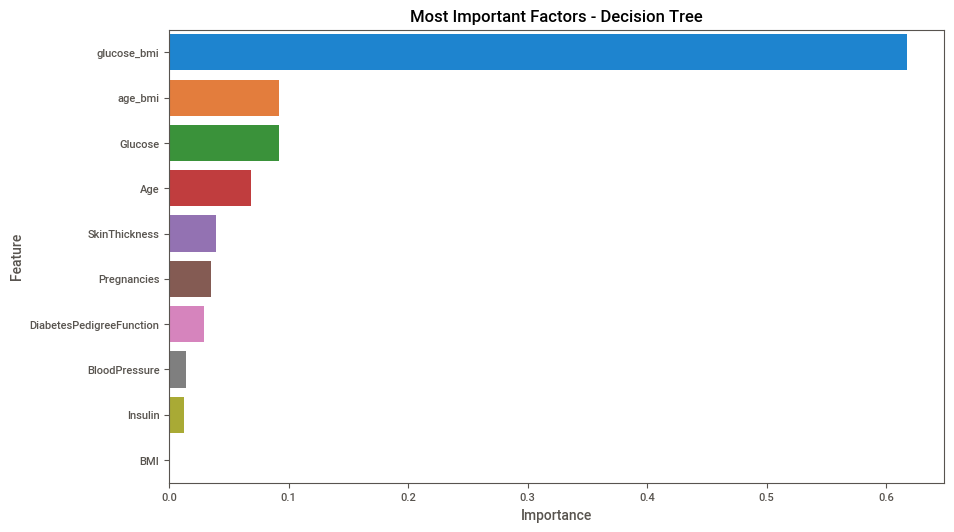


Calculating detailed feature impacts using SHAP values...


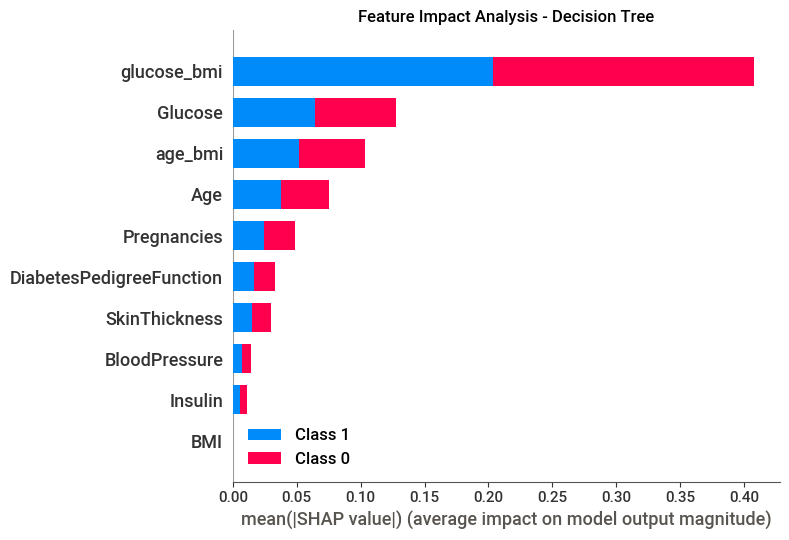


Training Random Forest...

Analyzing results for: Random Forest

How this algorithm works:

                Combines many decision trees, each looking at random subsets of the data.
                Like getting opinions from many experts and taking a vote.
                Strengths: Very accurate, handles complex patterns well
                Limitations: Less interpretable than single decision tree
            


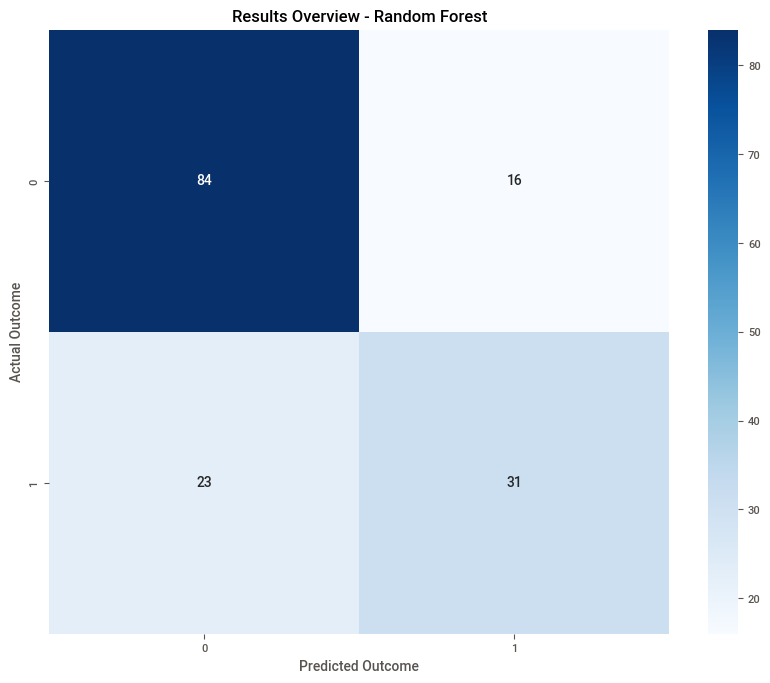


Business Impact Analysis:
Total patients analyzed: 154
Correct predictions: 115 (74.7%)
Missed diabetes cases: 23 (42.6% of actual cases)
False alarms: 16 (16.0% of healthy patients)


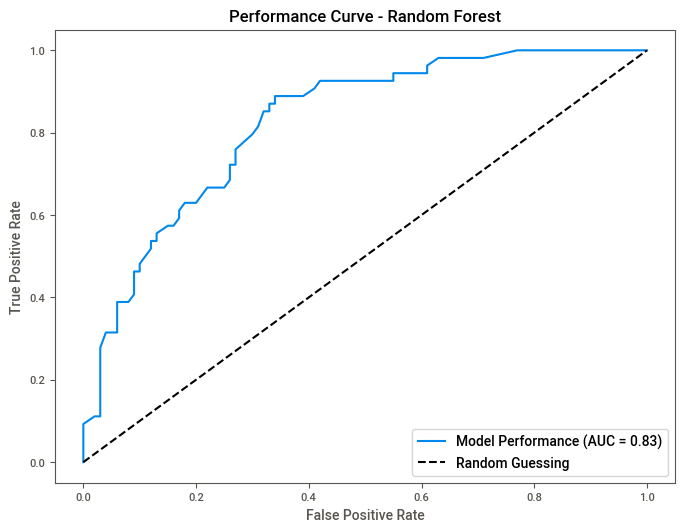


Analyzing which factors were most important for predictions...


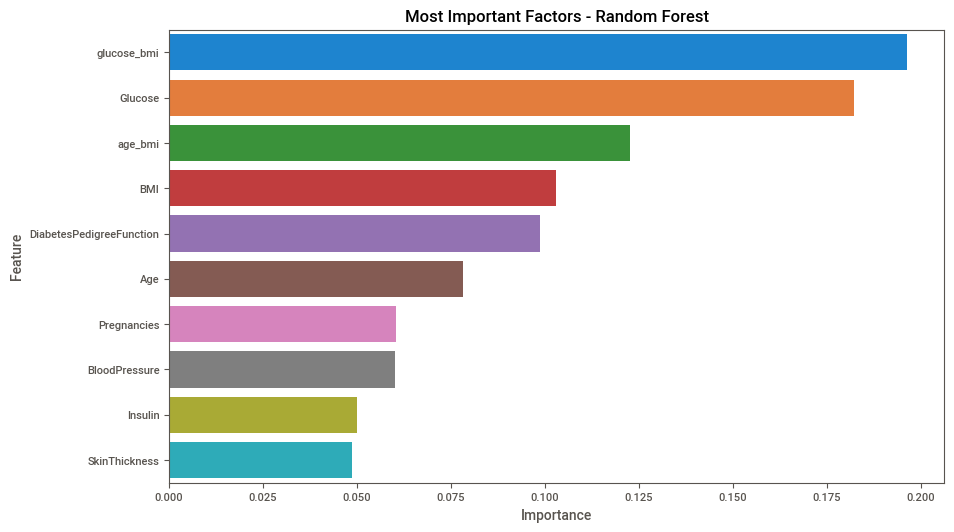


Calculating detailed feature impacts using SHAP values...


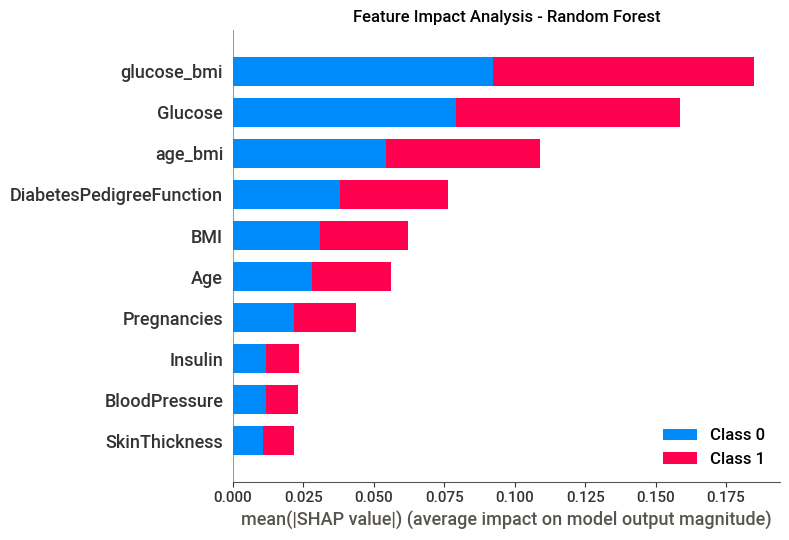


Training Gradient Boosting...

Analyzing results for: Gradient Boosting

How this algorithm works:

                Builds trees sequentially, each one focusing on correcting previous mistakes.
                Like an iterative improvement process in business.
                Strengths: Highly accurate, good with complex patterns
                Limitations: Can be sensitive to noisy data
            


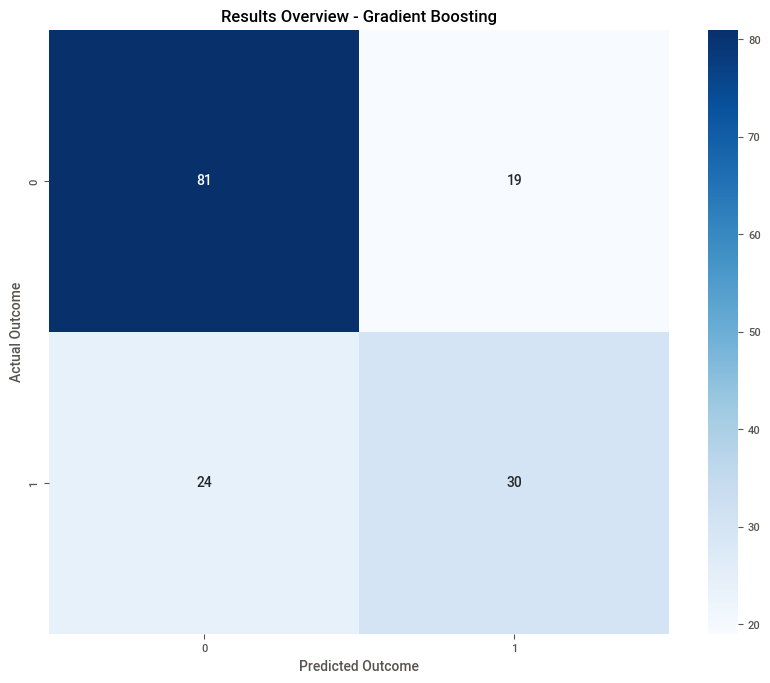


Business Impact Analysis:
Total patients analyzed: 154
Correct predictions: 111 (72.1%)
Missed diabetes cases: 24 (44.4% of actual cases)
False alarms: 19 (19.0% of healthy patients)


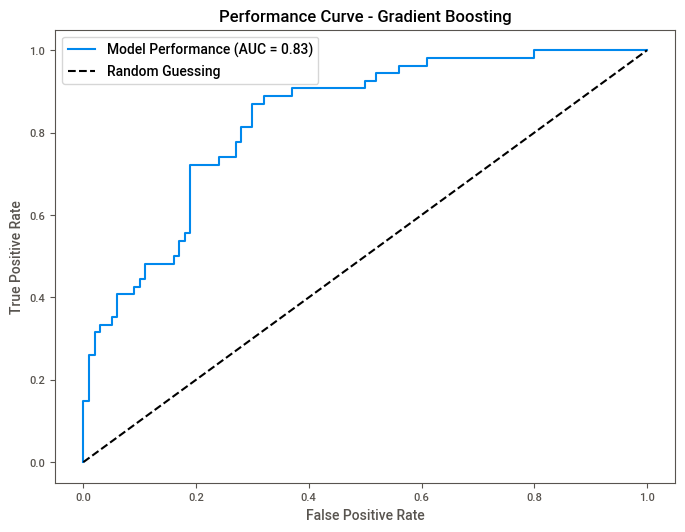


Analyzing which factors were most important for predictions...


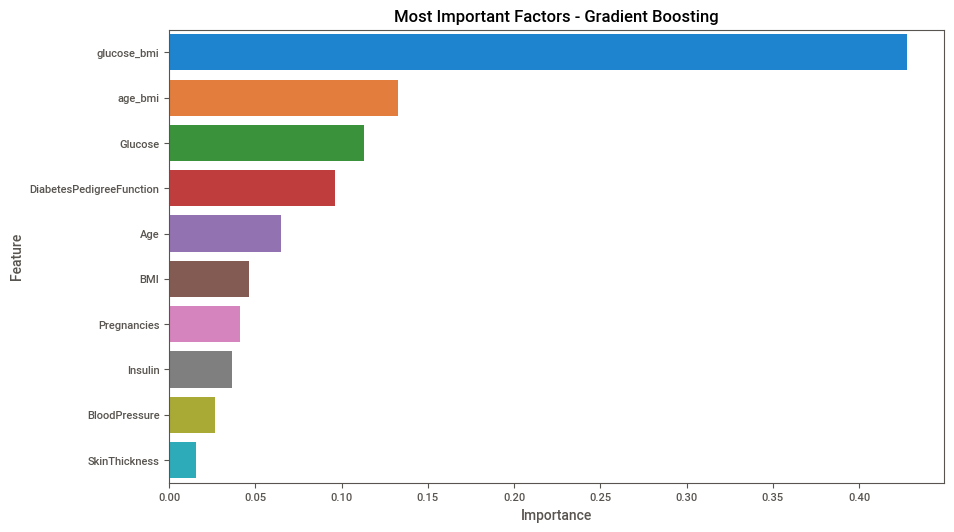


Calculating detailed feature impacts using SHAP values...


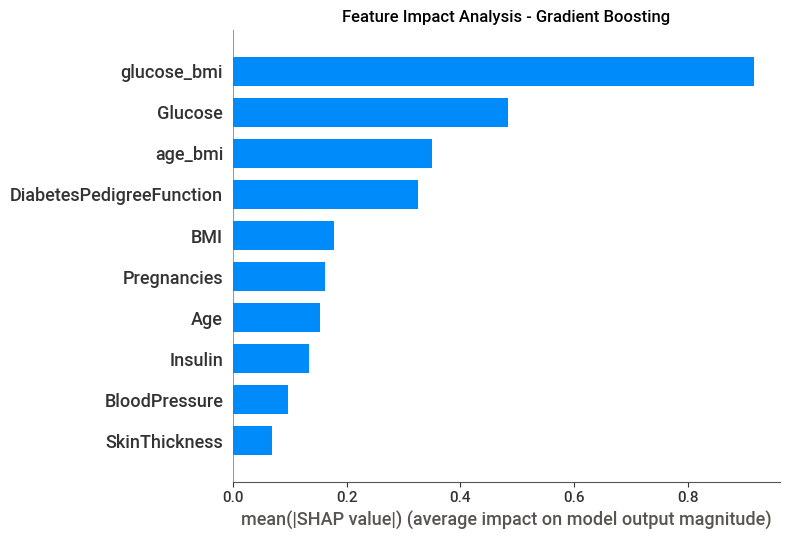


Training XGBoost...

Analyzing results for: XGBoost

How this algorithm works:

                An optimized version of gradient boosting that's faster and more accurate.
                Like having a highly efficient team that learns from past mistakes.
                Strengths: Top performance, handles missing data well
                Limitations: More parameters to tune
            


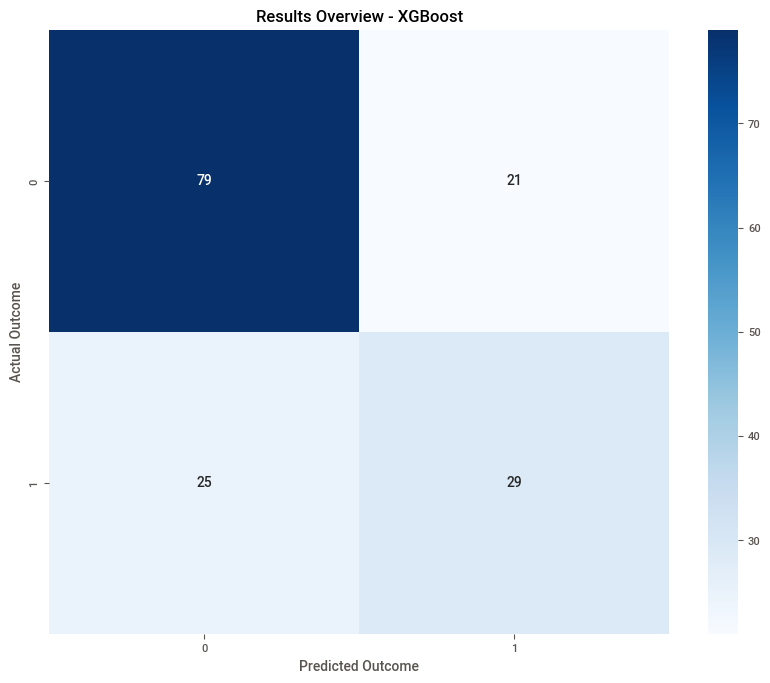


Business Impact Analysis:
Total patients analyzed: 154
Correct predictions: 108 (70.1%)
Missed diabetes cases: 25 (46.3% of actual cases)
False alarms: 21 (21.0% of healthy patients)


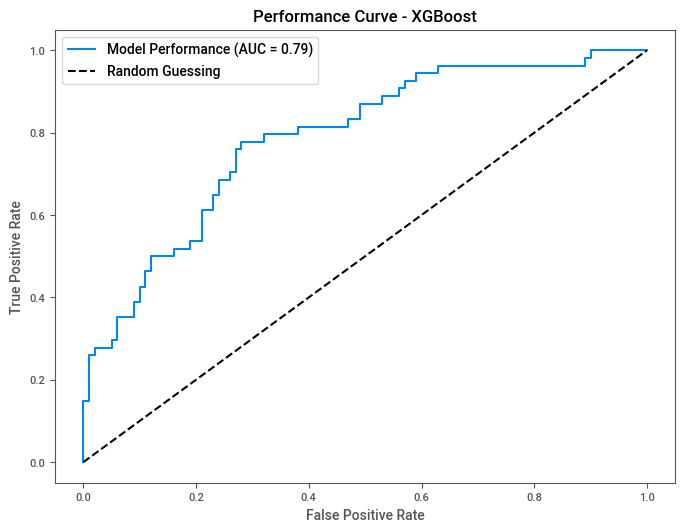


Analyzing which factors were most important for predictions...


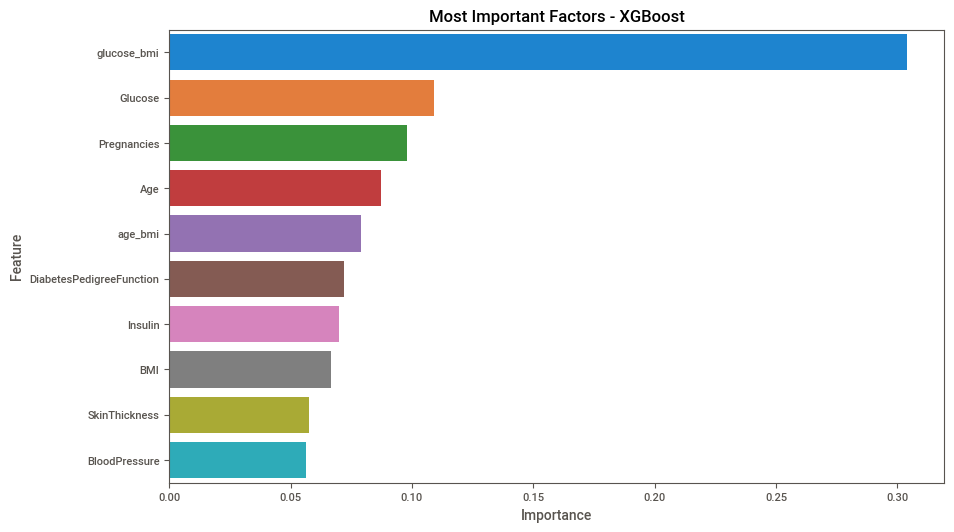


Calculating detailed feature impacts using SHAP values...


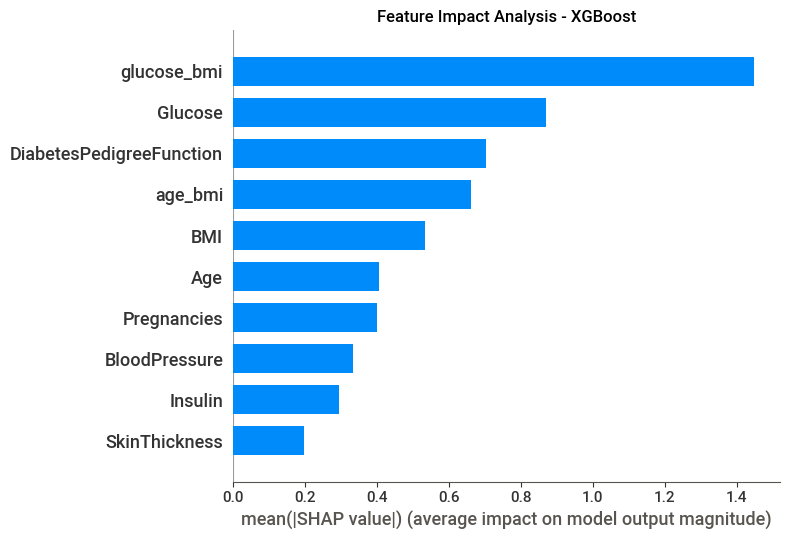


Training Neural Network...

Analyzing results for: Neural Network

How this algorithm works:

                Processes information through layers of interconnected nodes.
                Like having multiple departments collaborating on a decision.
                Strengths: Can learn very complex patterns
                Limitations: Needs lots of data, hard to interpret
            


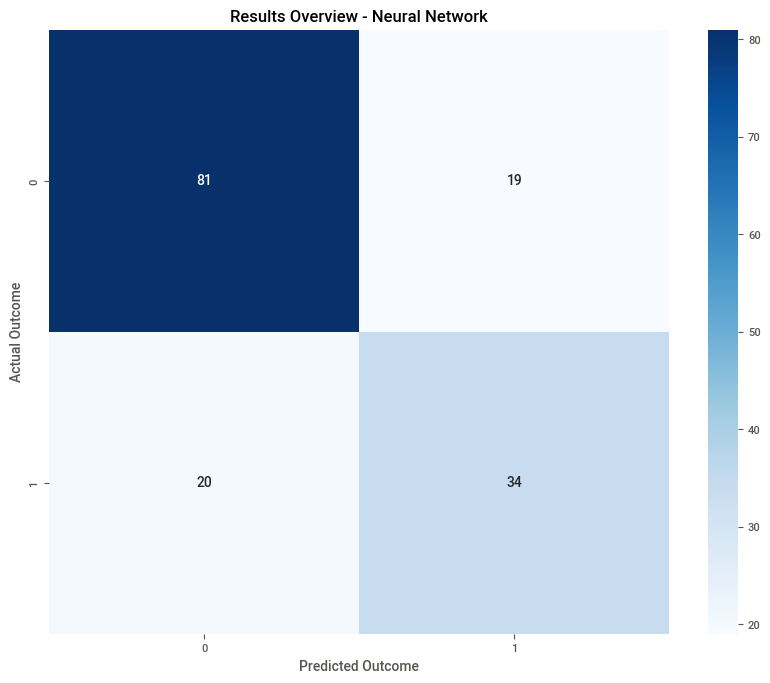


Business Impact Analysis:
Total patients analyzed: 154
Correct predictions: 115 (74.7%)
Missed diabetes cases: 20 (37.0% of actual cases)
False alarms: 19 (19.0% of healthy patients)


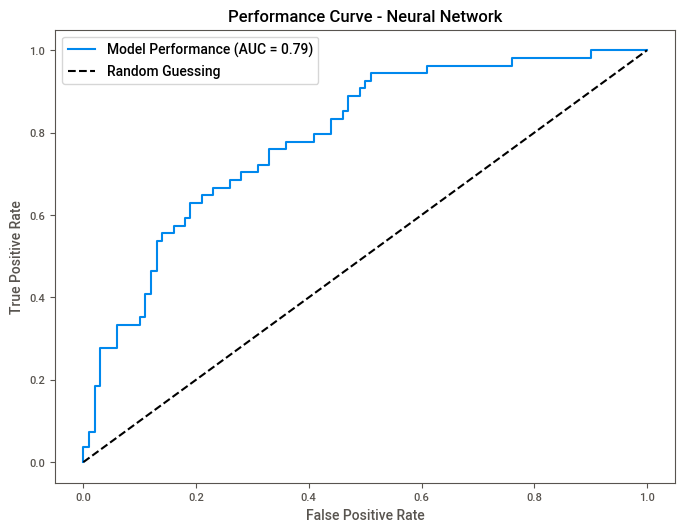


Training SVM...

Analyzing results for: SVM

How this algorithm works:

                Finds the best boundary between diabetic and non-diabetic cases.
                Like finding the clearest separation between customer segments.
                Strengths: Works well with clear patterns
                Limitations: Can be slow with large datasets
            


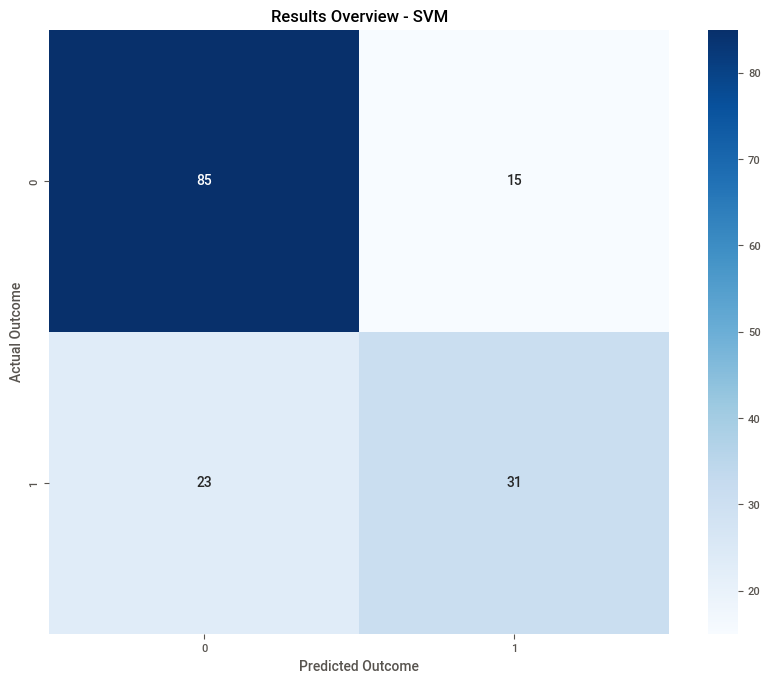


Business Impact Analysis:
Total patients analyzed: 154
Correct predictions: 116 (75.3%)
Missed diabetes cases: 23 (42.6% of actual cases)
False alarms: 15 (15.0% of healthy patients)


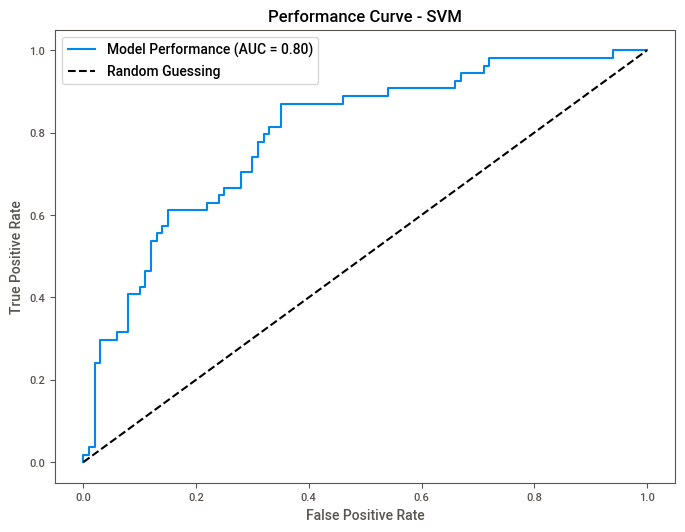


Training Naive Bayes...

Analyzing results for: Naive Bayes

How this algorithm works:

                Uses probability theory to make predictions based on feature frequencies.
                Like making quick judgments based on past patterns.
                Strengths: Fast, works well with small datasets
                Limitations: Assumes features are independent
            


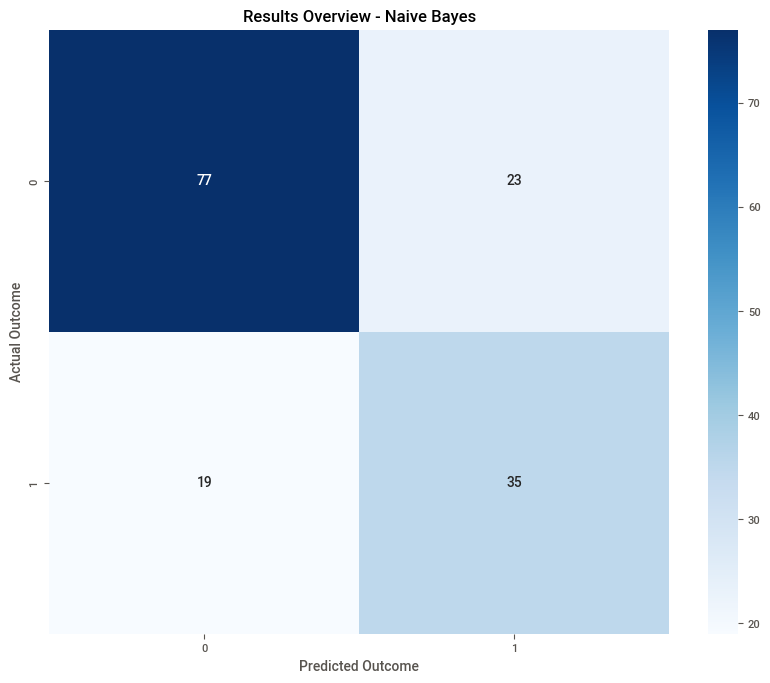


Business Impact Analysis:
Total patients analyzed: 154
Correct predictions: 112 (72.7%)
Missed diabetes cases: 19 (35.2% of actual cases)
False alarms: 23 (23.0% of healthy patients)


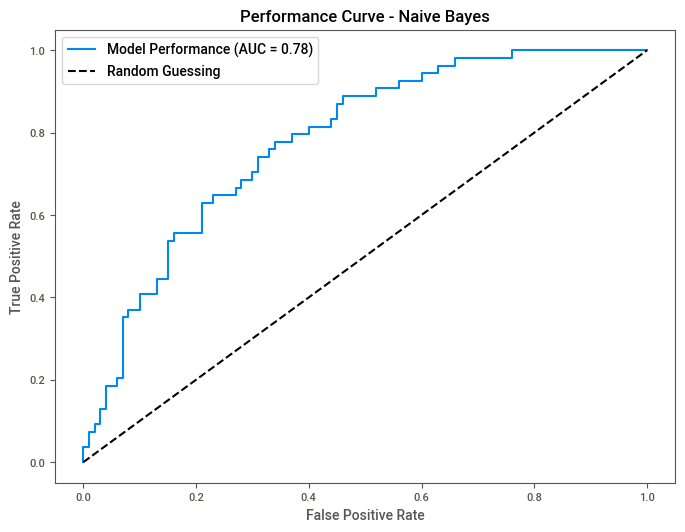


Creating comparative analysis of all models...


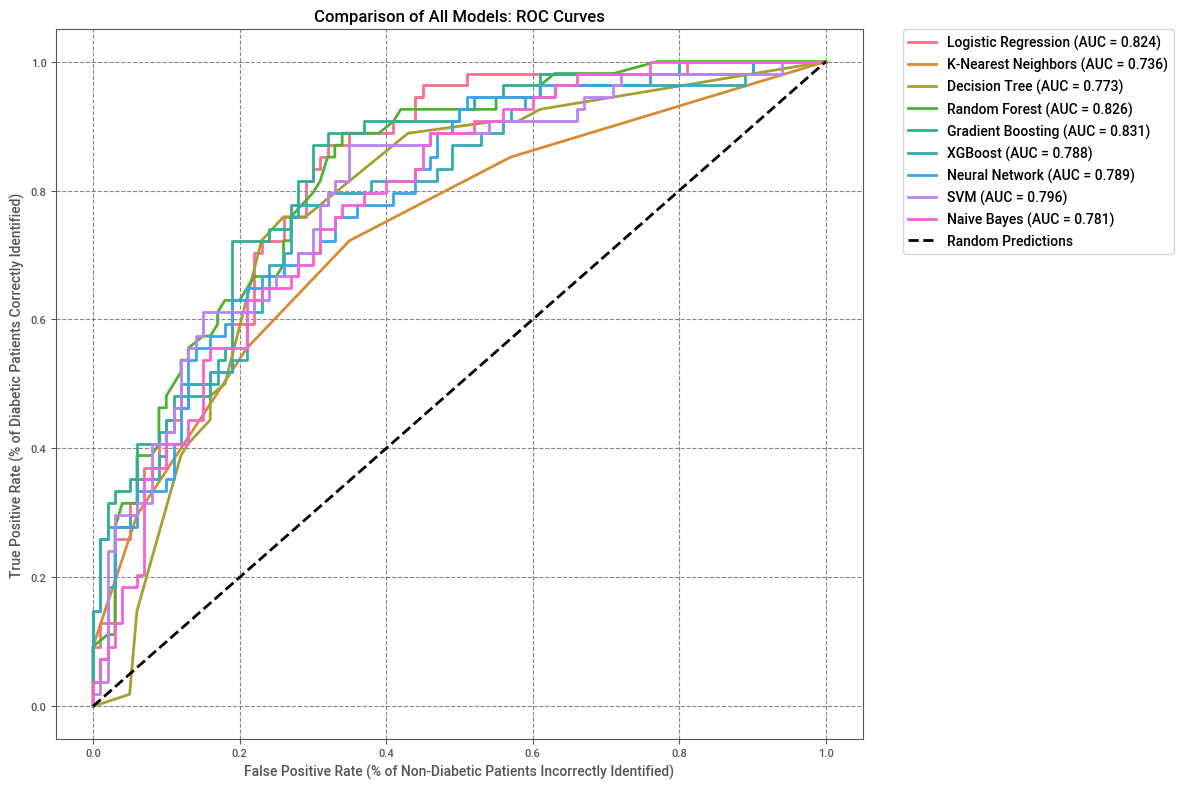


ROC Curve Interpretation:
------------------------
The ROC curve shows how well each model balances between:
1. Correctly identifying diabetic patients (True Positive Rate)
2. Minimizing false alarms for non-diabetic patients (False Positive Rate)

Key insights:
- A perfect model would reach the top-left corner (100% correct, 0% false alarms)
- The diagonal line represents random guessing
- The higher the curve and AUC score, the better the model's performance
- Models with similar curves may have different trade-offs in practice

Analysis complete!
Review the results above to compare how each model performed.
Pay special attention to:
1. The comparative ROC curves showing overall model performance
2. Individual model metrics and their business implications
3. The trade-offs between different models for your specific needs


In [4]:
# Comprehensive Diabetes Prediction Analysis
# A business-friendly implementation of machine learning algorithms
# Designed for graduate students with business background

# Part 1: Import necessary libraries
# These are like specialized tools we'll use for our analysis
import pandas as pd  # For handling data, similar to Excel but more powerful
import numpy as np  # For mathematical operations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt  # For creating visualizations
import seaborn as sns  # For enhanced visualizations
import shap  # For explaining model decisions
import warnings
warnings.filterwarnings('ignore')  # Hide technical warnings

from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report,
    roc_curve, 
    auc
)

# Import our collection of prediction algorithms
# Each algorithm represents a different approach to making predictions
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier


# Part 2: Create helper functions for data preparation and analysis
def load_and_prepare_data(filepath):
    """
    Loads and prepares the diabetes dataset for analysis.
    
    This function:
    1. Reads the data from a CSV file
    2. Creates helpful combined features
    3. Splits data into training and testing sets
    4. Scales the data to make it suitable for machine learning
    """
    print("Step 1: Loading and preparing the data...")
    
    # Read the CSV file
    data = pd.read_csv(filepath)
    
    # Create useful combined features (feature engineering)
    print("Creating combined features to help with predictions...")
    data['glucose_bmi'] = data['Glucose'] * data['BMI']  # Interaction between glucose and BMI
    data['age_bmi'] = data['Age'] * data['BMI']  # Interaction between age and BMI
    
    # Separate features (X) from what we want to predict (y)
    X = data.drop('Outcome', axis=1)
    y = data['Outcome']
    
    # Split into training and testing sets
    print("Splitting data into training and testing sets...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2,  # Use 20% for testing
        random_state=42,  # For reproducible results
        stratify=y  # Ensure balanced split
    )
    
    # Scale the features to be on the same scale
    print("Scaling features to be comparable...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Convert back to DataFrame to keep feature names
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
    
    return X_train_scaled, X_test_scaled, y_train, y_test

def create_models():
    """
    Creates a dictionary of all our prediction models with appropriate settings.
    Each model represents a different approach to making predictions.
    """
    return {
        'Logistic Regression': {
            'model': LogisticRegression(random_state=42),
            'explanation': """
                Logistic Regression is like drawing a line to separate diabetic from non-diabetic patients.
                It's similar to how credit scores combine different factors with weights.
                Strengths: Simple to understand, highly interpretable
                Limitations: May miss complex patterns
            """
        },
        'K-Nearest Neighbors': {
            'model': KNeighborsClassifier(n_neighbors=5),
            'explanation': """
                KNN finds the 5 most similar past cases and uses their outcomes to make a prediction.
                It's like Netflix recommending movies based on similar users' preferences.
                Strengths: Intuitive, no training needed
                Limitations: Can be slow with large datasets
            """
        },
        'Decision Tree': {
            'model': DecisionTreeClassifier(random_state=42, max_depth=5),
            'explanation': """
                Creates a flowchart of yes/no questions to reach a prediction.
                Similar to a customer service decision tree.
                Strengths: Very easy to understand, can visualize decisions
                Limitations: Can be unstable, may oversimplify
            """
        },
        'Random Forest': {
            'model': RandomForestClassifier(random_state=42, n_estimators=100),
            'explanation': """
                Combines many decision trees, each looking at random subsets of the data.
                Like getting opinions from many experts and taking a vote.
                Strengths: Very accurate, handles complex patterns well
                Limitations: Less interpretable than single decision tree
            """
        },
        'Gradient Boosting': {
            'model': GradientBoostingClassifier(random_state=42),
            'explanation': """
                Builds trees sequentially, each one focusing on correcting previous mistakes.
                Like an iterative improvement process in business.
                Strengths: Highly accurate, good with complex patterns
                Limitations: Can be sensitive to noisy data
            """
        },
        'XGBoost': {
            'model': XGBClassifier(random_state=42),
            'explanation': """
                An optimized version of gradient boosting that's faster and more accurate.
                Like having a highly efficient team that learns from past mistakes.
                Strengths: Top performance, handles missing data well
                Limitations: More parameters to tune
            """
        },

        'Neural Network': {
            'model': MLPClassifier(hidden_layer_sizes=(100,50), max_iter=1000, random_state=42),
            'explanation': """
                Processes information through layers of interconnected nodes.
                Like having multiple departments collaborating on a decision.
                Strengths: Can learn very complex patterns
                Limitations: Needs lots of data, hard to interpret
            """
        },
        'SVM': {
            'model': SVC(probability=True, random_state=42),
            'explanation': """
                Finds the best boundary between diabetic and non-diabetic cases.
                Like finding the clearest separation between customer segments.
                Strengths: Works well with clear patterns
                Limitations: Can be slow with large datasets
            """
        },
        'Naive Bayes': {
            'model': GaussianNB(),
            'explanation': """
                Uses probability theory to make predictions based on feature frequencies.
                Like making quick judgments based on past patterns.
                Strengths: Fast, works well with small datasets
                Limitations: Assumes features are independent
            """
        }
    }

def evaluate_model(model, X_test, y_test, model_name, explanation):
    """
    Evaluates a model's performance using multiple metrics and visualizations.
    Provides business-relevant interpretations of the results.
    """
    print(f"\n{'='*80}")
    print(f"Analyzing results for: {model_name}")
    print('='*80)
    
    # Print model explanation
    print("\nHow this algorithm works:")
    print(explanation)
    
    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate and visualize confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Results Overview - {model_name}')
    plt.ylabel('Actual Outcome')
    plt.xlabel('Predicted Outcome')
    plt.show()
    
    # Calculate business metrics
    total_cases = len(y_test)
    correct_predictions = cm[0,0] + cm[1,1]
    missed_cases = cm[1,0]  # False negatives
    false_alarms = cm[0,1]  # False positives
    
    print("\nBusiness Impact Analysis:")
    print(f"Total patients analyzed: {total_cases}")
    print(f"Correct predictions: {correct_predictions} ({(correct_predictions/total_cases):.1%})")
    print(f"Missed diabetes cases: {missed_cases} ({(missed_cases/sum(cm[1])):.1%} of actual cases)")
    print(f"False alarms: {false_alarms} ({(false_alarms/sum(cm[0])):.1%} of healthy patients)")
    
    # ROC curve and AUC score
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'Model Performance (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Performance Curve - {model_name}')
    plt.legend()
    plt.show()
    
    # Feature importance analysis
    if hasattr(model, 'feature_importances_'):
        print("\nAnalyzing which factors were most important for predictions...")
        feature_imp = pd.DataFrame({
            'Feature': X_test.columns,
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=False)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(data=feature_imp, x='Importance', y='Feature')
        plt.title(f'Most Important Factors - {model_name}')
        plt.show()
        
        # SHAP values for detailed feature impact
        print("\nCalculating detailed feature impacts using SHAP values...")
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
        
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
        plt.title(f'Feature Impact Analysis - {model_name}')
        plt.tight_layout()
        plt.show()

def plot_comparative_roc_curves(models_dict, X_test, y_test):
    """
    Creates a single plot comparing ROC curves for all models.
    
    This visualization helps us see which models are better at distinguishing between
    diabetic and non-diabetic patients. The higher the curve and the larger the AUC
    (Area Under Curve), the better the model's performance.
    """
    plt.figure(figsize=(12, 8))
    
    # Create a color palette for different models
    colors = sns.color_palette("husl", len(models_dict))
    
    # Plot ROC curve for each model
    for (name, model), color in zip(models_dict.items(), colors):
        # Get model predictions
        y_pred_proba = model['model'].predict_proba(X_test)[:, 1]
        
        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        
        # Plot the curve
        plt.plot(fpr, tpr, color=color, lw=2,
                label=f'{name} (AUC = {roc_auc:.3f})')
    
    # Add diagonal line representing random predictions
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Predictions')
    
    # Customize the plot
    plt.xlabel('False Positive Rate (% of Non-Diabetic Patients Incorrectly Identified)')
    plt.ylabel('True Positive Rate (% of Diabetic Patients Correctly Identified)')
    plt.title('Comparison of All Models: ROC Curves')
    
    # Adjust legend for readability
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    # Add grid for easier comparison
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    # Show the plot
    plt.show()
    
    # Print interpretative summary
    print("\nROC Curve Interpretation:")
    print("------------------------")
    print("The ROC curve shows how well each model balances between:")
    print("1. Correctly identifying diabetic patients (True Positive Rate)")
    print("2. Minimizing false alarms for non-diabetic patients (False Positive Rate)")
    print("\nKey insights:")
    print("- A perfect model would reach the top-left corner (100% correct, 0% false alarms)")
    print("- The diagonal line represents random guessing")
    print("- The higher the curve and AUC score, the better the model's performance")
    print("- Models with similar curves may have different trade-offs in practice")

def main():
    """
    Main function that runs our entire analysis pipeline
    """
    print("Starting Comprehensive Diabetes Prediction Analysis")
    print("================================================")
    print("\nThis analysis will:")
    print("1. Prepare the diabetes dataset")
    print("2. Train 10 different prediction models")
    print("3. Evaluate each model's performance")
    print("4. Provide business-relevant interpretations")
    print("\nStarting analysis...\n")
    
    # Load and prepare data
    X_train, X_test, y_train, y_test = load_and_prepare_data('diabetes.csv')
    
    # Create and train models
    models = create_models()
    
    # Train and evaluate each model
    for name, model_info in models.items():
        print(f"\nTraining {name}...")
        model = model_info['model']
        model.fit(X_train, y_train)
        
        # Evaluate model
        evaluate_model(
            model=model,
            X_test=X_test,
            y_test=y_test,
            model_name=name,
            explanation=model_info['explanation']
        )
    
    # Compare all models using ROC curves
    print("\nCreating comparative analysis of all models...")
    plot_comparative_roc_curves(models, X_test, y_test)
    
    print("\nAnalysis complete!")
    print("Review the results above to compare how each model performed.")
    print("Pay special attention to:")
    print("1. The comparative ROC curves showing overall model performance")
    print("2. Individual model metrics and their business implications")
    print("3. The trade-offs between different models for your specific needs")

if __name__ == "__main__":
    main()